# BeatSense — Data Pipeline Overview

Ноутбук демонстрирует:
- загрузку и базовый осмотр датасета ECG Heartbeat Categorization (MIT-BIH)
- визуализацию Data Flow всего проекта BeatSense

Источник данных: [Kaggle — ECG Heartbeat Categorization Dataset](https://www.kaggle.com/datasets/shayanfazeli/heartbeat)

## 1. Загрузка данных

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/raw/mitbih_train.csv', header=None)
df.columns = [str(i) for i in range(187)] + ['label']
df.head(5)

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,label
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87554 entries, 0 to 87553
Columns: 188 entries, 0 to label
dtypes: float64(188)
memory usage: 125.6 MB


In [4]:
CLASS_NAMES = {
    0: 'Normal',
    1: 'Supraventricular',
    2: 'Ventricular',
    3: 'Fusion',
    4: 'Unknown',
}

print('Распределение классов:')
print(df['label'].astype(int).map(CLASS_NAMES).value_counts())

Распределение классов:
label
Normal              72471
Unknown              6431
Ventricular          5788
Supraventricular     2223
Fusion                641
Name: count, dtype: int64


## 2. Data Flow проекта BeatSense

Ниже представлен Data Flow нашего проекта

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [6]:
G = nx.DiGraph()

nodes = [
    ('Kaggle',        'source'),
    ('data/raw/',     'storage'),
    ('Pandas',        'process'),
    ('MinMax + SMOTE','process'),
    ('data/processed/','storage'),
    ('PyTorch CNN',   'model'),
    ('Artifacts\n(.pt / .pkl)', 'storage'),
    ('FastAPI\n/predict',       'api'),
    ('Frontend\n(React)',       'ui'),
]

edges = [
    ('Kaggle',        'data/raw/',           'mitbih_train.csv\nmitbih_test.csv'),
    ('data/raw/',     'Pandas',              'read_csv'),
    ('Pandas',        'MinMax + SMOTE',      'X, y arrays'),
    ('MinMax + SMOTE','data/processed/',     'scaled + balanced'),
    ('data/processed/','PyTorch CNN',        'DataLoader'),
    ('PyTorch CNN',   'Artifacts\n(.pt / .pkl)', 'save model\n+ scaler'),
    ('Artifacts\n(.pt / .pkl)', 'FastAPI\n/predict', 'load at startup'),
    ('FastAPI\n/predict',       'Frontend\n(React)', 'JSON response\n{class, confidence}'),
]

for name, kind in nodes:
    G.add_node(name, kind=kind)

for src, dst, label in edges:
    G.add_edge(src, dst, label=label)

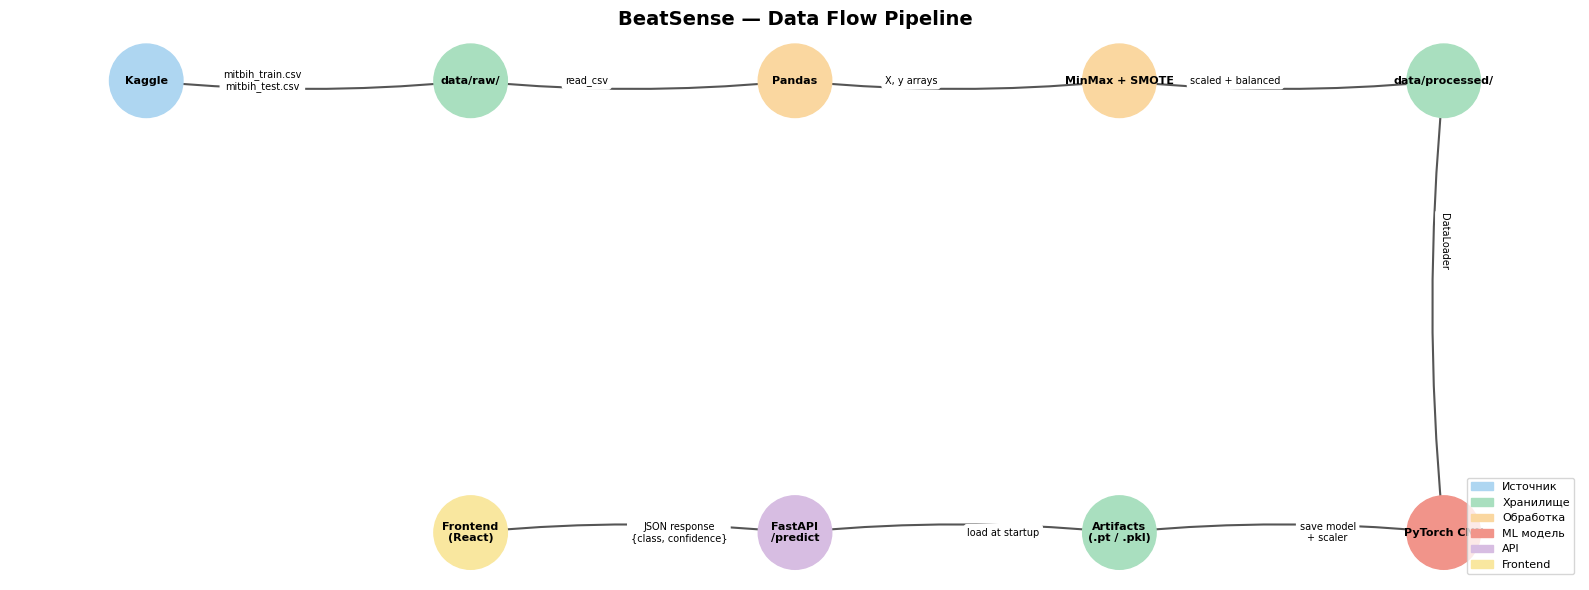

In [ ]:
COLOR_MAP = {
    'source':  '#AED6F1',
    'storage': '#A9DFBF',
    'process': '#FAD7A0',
    'model':   '#F1948A',
    'api':     '#D7BDE2',
    'ui':      '#F9E79F',
}

node_colors = [COLOR_MAP[G.nodes[n]['kind']] for n in G.nodes]

pos = {
    'Kaggle':                    (0, 4),
    'data/raw/':                 (2, 4),
    'Pandas':                    (4, 4),
    'MinMax + SMOTE':            (6, 4),
    'data/processed/':           (8, 4),
    'PyTorch CNN':               (8, 2),
    'Artifacts\n(.pt / .pkl)':   (6, 2),
    'FastAPI\n/predict':         (4, 2),
    'Frontend\n(React)':         (2, 2),
}

fig, ax = plt.subplots(figsize=(16, 6))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2800, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20,
                    edge_color='#555555', width=1.5,
                    connectionstyle='arc3,rad=0.05', ax=ax)

edge_labels = {(s, d): G.edges[s, d]['label'] for s, d in G.edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                            font_size=7, label_pos=0.35, ax=ax)

legend_patches = [
    mpatches.Patch(color='#AED6F1', label='Источник'),
    mpatches.Patch(color='#A9DFBF', label='Хранилище'),
    mpatches.Patch(color='#FAD7A0', label='Обработка'),
    mpatches.Patch(color='#F1948A', label='ML модель'),
    mpatches.Patch(color='#D7BDE2', label='API'),
    mpatches.Patch(color='#F9E79F', label='Frontend'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)

ax.set_title('BeatSense — Data Flow Pipeline', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()